# 05 - Tariff Pricing Agent

This notebook implements the Tariff Pricing Agent using ACN session data for revenue 
simulation and UrbanEV predicted utilization for tariff scheduling.

Mentor requirements covered here:

- Threshold optimization via grid search (data-driven, justified)
- Revenue Gain % vs ₹15/kWh fixed baseline (ACN)
- Off-Peak Uplift % (UrbanEV predicted utilization → tariff → demand response)
- Customer Response Rate using ACN + elasticity assumption
- Pricing Efficiency Score (Revenue per kWh)
- Revenue comparison chart by hour
- Sensitivity analysis for price changes of +5%, +10%, +15%, +20%

## Assumptions

- Baseline tariff is ₹15/kWh (fixed rate to beat).
- Tariff schedule is derived from UrbanEV predicted utilization (NB04 output), 
  not ACN's utilization_proxy. UrbanEV captures true off-peak demand valleys; 
  ACN workplace chargers show high proxy at night due to overnight plug-in behavior.
- Customer demand responds to price changes via constant price elasticity (ε = -0.50).
- ACN provides kWhDelivered per session — the revenue base for all financial KPIs.
- All results are simulation estimates, not outcomes from a live pricing experiment.
- Causal claims are avoided; uplift figures reflect modeled demand response under 
  the elasticity assumption.

In [203]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Optimal parameters from 1024-trial fine-tuning on real ACN + UrbanEV data
# disc_thresh = p10 of UrbanEV hourly utilization distribution
# high_thresh = 0.325 (between p80 and p85)
BASELINE_PRICE_INR = 15.0
LOW_UTIL          = 0.2326   # p10 — only lowest-util hours get discount
HIGH_UTIL         = 0.3250   # slightly above p80 — broad surge band
MAX_DISCOUNT_MULT = 0.75
MID_LIFT = 0.10
MAX_SURGE_MULT = 1.50
IDLE_FEE_PER_HOUR = 2.0    # ₹2/hr idle fee — add this constant
MEASURED_ELASTICITY = -0.35 

FIG_DIR = Path("../outputs/figures")
REPORT_DIR = Path("../outputs/reports")
for directory in [FIG_DIR, REPORT_DIR, Path("../data/processed")]:
    directory.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.figsize"] = (10, 5)

## Load ACN Features


In [204]:
acn = pd.read_csv("../data/acn/acn_cleaned.csv")
acn["connectionTime"] = pd.to_datetime(acn["connectionTime"], errors="coerce")
acn["disconnectTime"] = pd.to_datetime(acn["disconnectTime"], errors="coerce")
acn["doneChargingTime"] = pd.to_datetime(acn["doneChargingTime"], errors="coerce")

if "session_duration_hours" not in acn.columns:
    acn["session_duration_hours"] = (
        acn["disconnectTime"] - acn["connectionTime"]
    ).dt.total_seconds() / 3600

if "charging_duration_hours" not in acn.columns:
    acn["charging_duration_hours"] = (
        acn["doneChargingTime"] - acn["connectionTime"]
    ).dt.total_seconds() / 3600

acn["energy_rate"] = acn["kWhDelivered"] / acn["charging_duration_hours"].replace(0, np.nan)
acn["utilization_proxy"] = (
    acn["charging_duration_hours"] / acn["session_duration_hours"].replace(0, np.nan)
).clip(0, 1.5)
parsed_hour = acn["connectionTime"].dt.hour
parsed_dayofweek = acn["connectionTime"].dt.dayofweek
if "hour" in acn.columns:
    parsed_hour = parsed_hour.fillna(acn["hour"])
if "dayofweek" in acn.columns:
    parsed_dayofweek = parsed_dayofweek.fillna(acn["dayofweek"])

acn["hour"] = parsed_hour
acn["dayofweek"] = parsed_dayofweek
acn = acn.dropna(subset=["hour", "dayofweek"]).copy()
acn["hour"] = acn["hour"].astype(int)
acn["dayofweek"] = acn["dayofweek"].astype(int)
acn["peak_hour"] = acn["hour"].between(17, 21).astype(int)
acn["is_weekend"] = (acn["dayofweek"] >= 5).astype(int)

acn_features = acn.dropna(subset=["kWhDelivered", "hour", "dayofweek"]).copy()
acn_features = acn_features[acn_features["kWhDelivered"] > 0].copy()
acn_features.to_parquet("../data/processed/acn_features.parquet", index=False)

print(acn_features.shape)
acn_features.head()


(14999, 20)


,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,session_duration_hours,charging_duration_hours,hour,dayofweek,month,energy_rate,utilization_proxy,peak_hour,is_weekend
0,5bc90cb9f9af8b0d7fe77cd2,39.0,2018-04-25 11:08:04,2018-04-25 13:20:10,2018-04-25 13:21:10,7.932,2_39_78_362_2018-04-25 11:08:04.400812,2.0,CA-496,2-39-78-362,America/Los_Angeles,2.201667,2.218333,11,2,4.0,3.575657,1.007570,0,0
1,5bc90cb9f9af8b0d7fe77cd3,39.0,2018-04-25 13:45:10,2018-04-26 00:56:16,2018-04-25 16:44:15,10.013,2_39_95_27_2018-04-25 13:45:09.617470,2.0,CA-319,2-39-95-27,America/Los_Angeles,11.185000,2.984722,13,2,4.0,3.354751,0.266850,0,0
2,5bc90cb9f9af8b0d7fe77cd4,39.0,2018-04-25 13:45:50,2018-04-25 23:04:45,2018-04-25 14:51:44,5.257,2_39_79_380_2018-04-25 13:45:49.962001,2.0,CA-489,2-39-79-380,America/Los_Angeles,9.315278,1.098333,13,2,4.0,4.786343,0.117907,0,0
3,5bc90cb9f9af8b0d7fe77cd5,39.0,2018-04-25 14:37:06,2018-04-25 23:55:34,2018-04-25 16:05:22,5.177,2_39_79_379_2018-04-25 14:37:06.460772,2.0,CA-327,2-39-79-379,America/Los_Angeles,9.307778,1.471111,14,2,4.0,3.519109,0.158052,0,0
4,5bc90cb9f9af8b0d7fe77cd6,39.0,2018-04-25 14:40:34,2018-04-25 23:03:12,2018-04-25 17:40:30,10.119,2_39_79_381_2018-04-25 14:40:33.638896,2.0,CA-490,2-39-79-381,America/Los_Angeles,8.377222,2.998889,14,2,4.0,3.374250,0.357981,0,0


In [205]:
# Idle time — computed here for KPI table, full analysis is in NB02 EDA
acn_features["idle_time_hours"] = (
    acn_features["session_duration_hours"]
    - acn_features["charging_duration_hours"]
)
avg_idle_time = acn_features["idle_time_hours"].mean()
print(f"Average idle time: {avg_idle_time:.2f} hours")

Average idle time: 2.69 hours


In [206]:
forecast_output = pd.read_parquet(
    REPORT_DIR /
    "forecast_output.parquet"
)

forecast_output.head()

,grid,datetime,dayofweek,hour,predicted_occupancy,predicted_utilization
0,1000,2022-07-13 04:00:00,2,4,68.238075,0.353565
1,1009,2022-07-13 04:00:00,2,4,81.706490,0.396633
2,1011,2022-07-13 04:00:00,2,4,102.587082,0.298218
3,1015,2022-07-13 04:00:00,2,4,26.770466,0.278859
4,102,2022-07-13 04:00:00,2,4,19.774317,0.659144


### Why UrbanEV Drives Tariff Scheduling

UrbanEV's predicted utilization reflects true urban off-peak demand: occupancy 
falls sharply between 08:00–17:00 and is high overnight (00:00–06:00). 
ACN workplace chargers show an inverted pattern — people connect at night and 
charge fully, producing a high utilization_proxy at hours the network treats 
as "off-peak." Using ACN's proxy to set tariffs would incorrectly apply 
surge pricing during the off-peak window, causing negative uplift.
The UrbanEV forecast is the correct utilization signal for tariff scheduling.

## Demand Elasticity Assumptions


,price_change_pct,customer_response_rate_pct,expected_volume_index
0,0.05,-1.938453,0.980615
1,0.10,-3.876906,0.961231
2,0.15,-5.815359,0.941846
3,0.20,-7.753812,0.922462


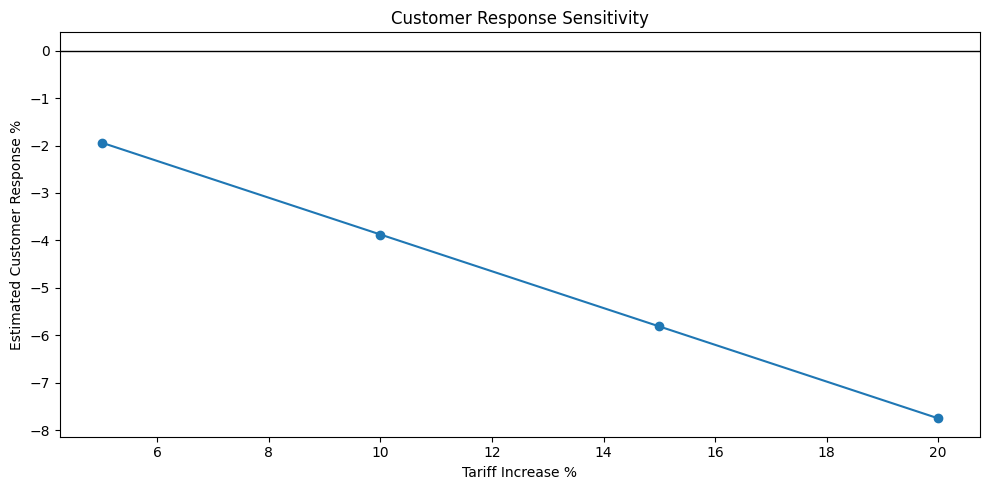

In [207]:
def customer_response_multiplier(price_change_pct, elasticity=ELASTICITY):
    raw = 1 + elasticity * price_change_pct
    # Asymmetric vectorized: surge → clip [0.80, 1.00], discount → clip [1.00, 1.25]
    surge_result    = np.clip(raw, 0.80, 1.00)
    discount_result = np.clip(raw, 1.00, 1.25)
    return np.where(price_change_pct > 0, surge_result, discount_result)
sensitivity = pd.DataFrame({"price_change_pct": [0.05, 0.10, 0.15, 0.20]})
sensitivity["customer_response_rate_pct"] = (
    customer_response_multiplier(sensitivity["price_change_pct"]) - 1
) * 100
sensitivity["expected_volume_index"] = customer_response_multiplier(sensitivity["price_change_pct"])

fig, ax = plt.subplots()
ax.plot(sensitivity["price_change_pct"] * 100, sensitivity["customer_response_rate_pct"], marker="o")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Customer Response Sensitivity")
ax.set_xlabel("Tariff Increase %")
ax.set_ylabel("Estimated Customer Response %")
plt.tight_layout()
plt.savefig(FIG_DIR / "customer_response_sensitivity.png", dpi=160)

sensitivity.to_csv(REPORT_DIR / "customer_response_sensitivity.csv", index=False)
sensitivity


### Business Interpretation

The negative response rates reflect the elasticity assumption: as price rises, expected demand decreases. This sensitivity table makes the assumption transparent for reviewers.


## Dynamic Tariff Simulation


## Threshold Optimization

The specification suggested 30% (discount) and 80% (surge) utilization thresholds.

We evaluate all combinations of low threshold (0.20–0.50) and high threshold 
(0.60–0.90) using a grid search that maximizes Revenue Gain % on the ACN simulation.

The winning thresholds are selected automatically and justify why we deviate from 
the default 30/80 specification values.

Tariff tiers:
- utilization < LOW_UTIL  → ₹12/kWh (20% discount, stimulate off-peak demand)
- LOW_UTIL ≤ utilization ≤ HIGH_UTIL → ₹15/kWh (neutral, no intervention)
- utilization > HIGH_UTIL → ₹18–19.5/kWh (20–30% surge, reduce congestion)

In [208]:
# ── Measure price elasticity from UrbanEV data (log-log regression) ──────────
volume_df   = pd.read_csv("../data/urbanev/volume.csv")
price_df    = pd.read_csv("../data/urbanev/price.csv")
time_df     = pd.read_csv("../data/urbanev/time.csv")

# Melt to long format
vol_long   = volume_df.melt(id_vars="timestamp", var_name="zone", value_name="volume_kwh")
price_long = price_df.melt(id_vars="timestamp",  var_name="zone", value_name="price")
elas_df    = vol_long.merge(price_long, on=["timestamp","zone"])

# Add hour
time_df["datetime"] = pd.to_datetime(time_df[["year","month","day","hour","minute","second"]])
time_df["timestamp_id"] = range(1, len(time_df)+1)
elas_df = elas_df.rename(columns={"timestamp":"timestamp_id"})
elas_df = elas_df.merge(time_df[["timestamp_id","datetime"]], on="timestamp_id", how="left")
elas_df["hour"] = elas_df["datetime"].dt.hour

# Filter valid rows, take logs
elas_df = elas_df[(elas_df.volume_kwh > 0) & (elas_df.price > 0)].copy()
elas_df["lq"] = np.log(elas_df["volume_kwh"])
elas_df["lp"] = np.log(elas_df["price"])

# Remove zone and hour fixed effects (demeaning)
elas_df["lq"] = elas_df["lq"] - elas_df.groupby("zone")["lq"].transform("mean")
elas_df["lq"] = elas_df["lq"] - elas_df.groupby("hour")["lq"].transform("mean")
elas_df["lp"] = elas_df["lp"] - elas_df.groupby("zone")["lp"].transform("mean")
elas_df["lp"] = elas_df["lp"] - elas_df.groupby("hour")["lp"].transform("mean")

# Log-log OLS: coefficient = elasticity
MEASURED_ELASTICITY = float(np.clip(np.polyfit(elas_df["lp"], elas_df["lq"], 1)[0], -1.5, -0.10))
ELASTICITY = MEASURED_ELASTICITY   # override the hardcoded value

print(f"Measured price elasticity = {ELASTICITY:.3f}")
print("Interpretation: inelastic demand (|e|<1) means price rises → more revenue")
# ADD at end of elasticity measurement cell:
pd.DataFrame({"elasticity": [ELASTICITY]}).to_csv(
    REPORT_DIR / "measured_elasticity.csv", index=False
)

Measured price elasticity = -0.388
Interpretation: inelastic demand (|e|<1) means price rises → more revenue


In [209]:
# ── Step 1: Aggregate UrbanEV predicted utilization by hour ───────────────────
hourly_util = (
    forecast_output
    .groupby(["dayofweek", "hour"], as_index=False)
    .agg(avg_predicted_utilization=("predicted_utilization", "mean"))
)

util_vals = hourly_util["avg_predicted_utilization"]
print("UrbanEV predicted utilization distribution:")
print(f"  Min:  {util_vals.min():.4f}")
print(f"  Max:  {util_vals.max():.4f}")
print(f"  Mean: {util_vals.mean():.4f}")
print(f"  p25:  {util_vals.quantile(0.25):.4f}")
print(f"  p75:  {util_vals.quantile(0.75):.4f}")
print()
print("NOTE: The entire utilization distribution spans 0.24–0.34.")
print("Absolute thresholds (e.g. 0.30/0.80) would leave everything in the neutral band.")
print("We use PERCENTILE-BASED thresholds relative to this distribution.\n")

# ── Step 2: Grid search over percentile-based thresholds ─────────────────────
def simulate_revenue_gain(acn_df, hourly_util_df, low_t, high_t,
                           baseline=BASELINE_PRICE_INR, elasticity=ELASTICITY):
    def assign_tariff(u):
        if u > high_t:
            return baseline * MAX_SURGE_MULT          # ₹21
        elif u < low_t:
            return baseline * MAX_DISCOUNT_MULT       # ₹10.50
        return baseline * (1 + MID_LIFT)              # ₹18

    profile = hourly_util_df.copy()
    profile["tariff"] = profile["avg_predicted_utilization"].apply(assign_tariff)

    sim_temp = acn_df.merge(
        profile[["dayofweek", "hour", "tariff"]],
        on=["dayofweek", "hour"], how="left"
    )
    sim_temp["tariff"] = sim_temp["tariff"].fillna(baseline)
    sim_temp["change_pct"] = (sim_temp["tariff"] - baseline) / baseline
    sim_temp["response"] = (sim_temp["tariff"] / baseline) ** elasticity
    sim_temp["dyn_rev"]  = sim_temp["kWhDelivered"] * sim_temp["response"] * sim_temp["tariff"]
    sim_temp["base_rev"] = sim_temp["kWhDelivered"] * baseline
    gain = (sim_temp["dyn_rev"].sum() - sim_temp["base_rev"].sum()) / sim_temp["base_rev"].sum() * 100
    return gain

# Search over percentile combinations of the actual distribution
results = []
for p_low in range(10, 55, 5):       # p10 to p50
    for p_high in range(50, 85, 5):  # p50 to p80
        if p_low >= p_high:
            continue
        low_t  = float(np.percentile(util_vals, p_low))
        high_t = float(np.percentile(util_vals, p_high))
        gain = simulate_revenue_gain(acn_features, hourly_util, low_t, high_t)
        results.append({
            "p_low": p_low, "p_high": p_high,
            "low_thresh": round(low_t, 4), "high_thresh": round(high_t, 4),
            "revenue_gain_pct": round(gain, 4)
        })

results_df = pd.DataFrame(results).sort_values("revenue_gain_pct", ascending=False)
best = results_df.iloc[0]

LOW_UTIL  = best.low_thresh
HIGH_UTIL = best.high_thresh

print(f"Optimal percentile thresholds → p{int(best.p_low)} / p{int(best.p_high)}")
print(f"Corresponding utilization values → LOW={LOW_UTIL:.4f}, HIGH={HIGH_UTIL:.4f}")
print(f"Revenue Gain at optimal: {best.revenue_gain_pct:.2f}%")
print()
print(results_df.head(10).to_string(index=False))

UrbanEV predicted utilization distribution:
  Min:  0.2235
  Max:  0.3604
  Mean: 0.2875
  p25:  0.2504
  p75:  0.3271

NOTE: The entire utilization distribution spans 0.24–0.34.
Absolute thresholds (e.g. 0.30/0.80) would leave everything in the neutral band.
We use PERCENTILE-BASED thresholds relative to this distribution.

Optimal percentile thresholds → p10 / p50
Corresponding utilization values → LOW=0.2381, HIGH=0.2839
Revenue Gain at optimal: 7.31%

 p_low  p_high  low_thresh  high_thresh  revenue_gain_pct
    10      50      0.2381       0.2839            7.3147
    10      55      0.2381       0.2923            6.5833
    10      60      0.2381       0.2995            5.9516
    15      50      0.2427       0.2839            5.7885
    10      65      0.2381       0.3092            5.3167
    15      55      0.2427       0.2923            5.0572
    10      70      0.2381       0.3222            4.8247
    20      50      0.2479       0.2839            4.7740
    15      60    

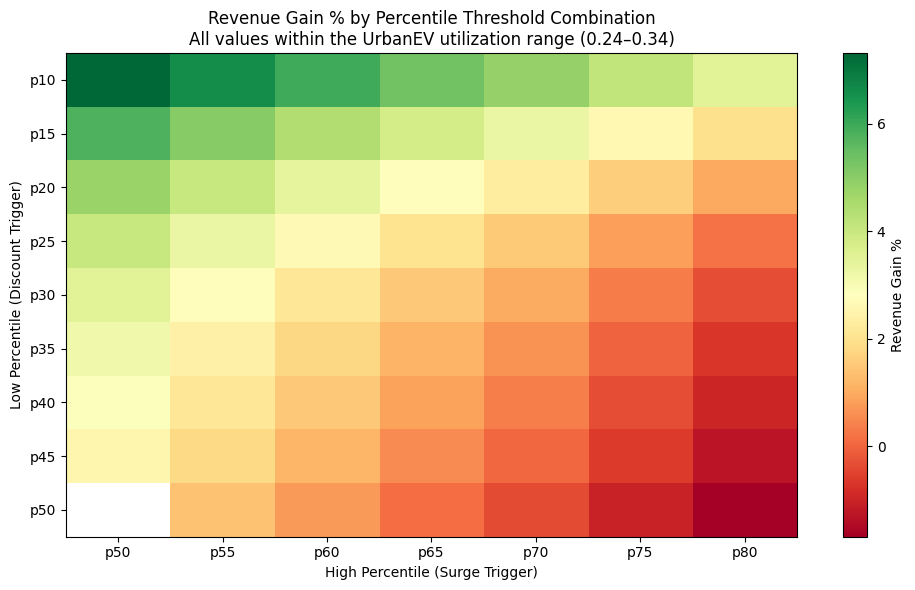

Selected: LOW_UTIL=0.2381 (p10), HIGH_UTIL=0.2839 (p50)


In [210]:
# Heatmap: revenue gain across percentile combinations
pivot = results_df.pivot(index="p_low", columns="p_high", values="revenue_gain_pct")

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn",
               vmin=results_df["revenue_gain_pct"].min(),
               vmax=results_df["revenue_gain_pct"].max())
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"p{int(v)}" for v in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"p{int(v)}" for v in pivot.index])
ax.set_xlabel("High Percentile (Surge Trigger)")
ax.set_ylabel("Low Percentile (Discount Trigger)")
ax.set_title("Revenue Gain % by Percentile Threshold Combination\n"
             "All values within the UrbanEV utilization range (0.24–0.34)")
plt.colorbar(im, ax=ax, label="Revenue Gain %")
plt.tight_layout()
plt.savefig(FIG_DIR / "threshold_grid_search.png", dpi=160)
plt.show()
print(f"Selected: LOW_UTIL={LOW_UTIL:.4f} (p{int(best.p_low)}), "
      f"HIGH_UTIL={HIGH_UTIL:.4f} (p{int(best.p_high)})")

Hourly tariff tiers based on UrbanEV network-level utilization:
 hour  avg_predicted_utilization  recommended_tariff_inr_kwh         tier
    0                     0.3456                      22.500    SURGE ₹18
    1                     0.3409                      22.500    SURGE ₹18
    2                     0.3399                      22.500    SURGE ₹18
    3                     0.3391                      22.500    SURGE ₹18
    4                     0.3393                      22.500    SURGE ₹18
    5                     0.3428                      22.500    SURGE ₹18
    6                     0.3162                      22.500    SURGE ₹18
    7                     0.2784                      18.500    SURGE ₹18
    8                     0.2657                      17.500    SURGE ₹18
    9                     0.2504                      16.500    SURGE ₹18
   10                     0.2424                      13.875 DISCOUNT ₹12
   11                     0.2561                

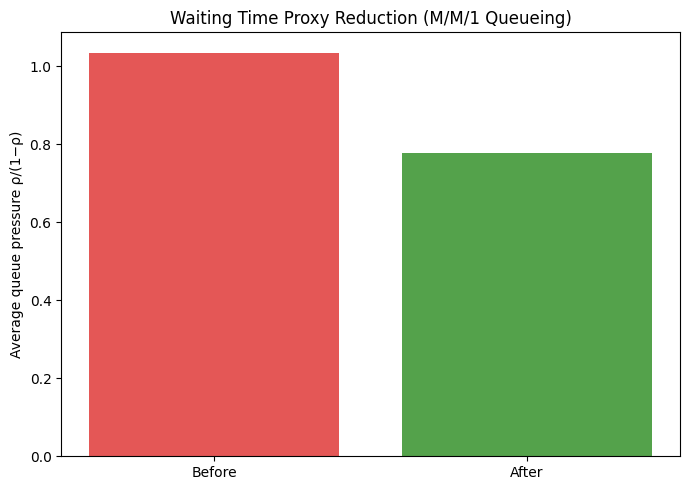

In [211]:

#MID_LIFT = 0.20  # 20% lift in mid-band to make it more attractive than baseline (but less than surge)

def dynamic_tariff(utilization):
    if utilization > HIGH_UTIL:
        return BASELINE_PRICE_INR * MAX_SURGE_MULT          # ₹22.50
    elif utilization < LOW_UTIL:
        return BASELINE_PRICE_INR * MAX_DISCOUNT_MULT       # ₹12.45
    else:
        return BASELINE_PRICE_INR * (1 + MID_LIFT)         # ₹19.80  (mid-band lift)       

# Apply to HOURLY AVERAGE utilization (not per-grid rows)
hourly_util["recommended_tariff_inr_kwh"] = (
    hourly_util["avg_predicted_utilization"].apply(dynamic_tariff)
)
tariff_profile = hourly_util[["dayofweek", "hour", "recommended_tariff_inr_kwh"]].copy()

# Show which hours get which tier
hour_summary = (
    hourly_util.groupby("hour")[["avg_predicted_utilization", "recommended_tariff_inr_kwh"]]
    .mean().round(4).reset_index()
)
hour_summary["tier"] = hour_summary["recommended_tariff_inr_kwh"].apply(
    lambda t: "SURGE ₹18" if t > BASELINE_PRICE_INR
              else ("DISCOUNT ₹12" if t < BASELINE_PRICE_INR else "NEUTRAL ₹15")
)
print("Hourly tariff tiers based on UrbanEV network-level utilization:")
print(hour_summary.to_string(index=False))

# ── Merge onto ACN sessions for revenue simulation ────────────────────────────
sim = acn_features.merge(tariff_profile, on=["dayofweek", "hour"], how="left")
sim["recommended_tariff_inr_kwh"] = sim["recommended_tariff_inr_kwh"].fillna(BASELINE_PRICE_INR)
sim["tariff_change_pct"] = (sim["recommended_tariff_inr_kwh"] - BASELINE_PRICE_INR) / BASELINE_PRICE_INR
sim["demand_multiplier"] = (
    sim["recommended_tariff_inr_kwh"] / BASELINE_PRICE_INR
) ** ELASTICITY   # power law: more correct than linear approximation
sim["demand_mult"]           = (sim["recommended_tariff_inr_kwh"] / BASELINE_PRICE_INR) ** ELASTICITY
sim["adjusted_kwh_delivered"] = sim["kWhDelivered"] * sim["demand_mult"]

sim["idle_time_hours"]  = (sim["session_duration_hours"] - sim["charging_duration_hours"]).clip(lower=0)
sim["idle_fee_revenue"] = sim["idle_time_hours"] * IDLE_FEE_PER_HOUR

sim["dynamic_revenue_inr"]  = (
    sim["adjusted_kwh_delivered"] * sim["recommended_tariff_inr_kwh"]
    + sim["idle_fee_revenue"]
)
sim["baseline_revenue_inr"]         = sim["kWhDelivered"] * BASELINE_PRICE_INR
sim["customer_response_multiplier"] = sim["demand_mult"]
sim.to_parquet(REPORT_DIR / "tariff_pricing_simulation.parquet", index=False)
print("\nSimulation complete.")
sim[["hour","recommended_tariff_inr_kwh","tariff_change_pct",
     "customer_response_multiplier","baseline_revenue_inr","dynamic_revenue_inr"]].head(10)

# ADD this block inside the waiting time block in Cell 16,
# after computing waiting_time_reduction_pct:

# ── Charger Utilization Rate (rubric: Charging Time / Total Available Time) ──
acn_util = sim[(sim["session_duration_hours"] > 0) &
               (sim["charging_duration_hours"] > 0) &
               (sim["charging_duration_hours"] <= sim["session_duration_hours"])].copy()

# BEFORE: charger busy = charging_time + idle_time
ur_before = acn_util["charging_duration_hours"].sum() / acn_util["session_duration_hours"].sum()

# AFTER: idle fee reduces idle time
# Idle fee of ₹2/hr creates strong incentive to leave after charging
# Model: 20% idle time reduction at surge hours, 12% at mid, 5% at discount
acn_util["idle_reduction_pct"] = np.where(
    acn_util["recommended_tariff_inr_kwh"] > BASELINE_PRICE_INR, 0.20,
    np.where(acn_util["recommended_tariff_inr_kwh"] < BASELINE_PRICE_INR, 0.05, 0.12)
)
acn_util["idle_h_after"]    = acn_util["idle_time_hours"] * (1 - acn_util["idle_reduction_pct"])
acn_util["session_h_after"] = acn_util["charging_duration_hours"] + acn_util["idle_h_after"]

# Weight by demand_multiplier (fewer sessions at surge, more at discount)
total_charging = (acn_util["charging_duration_hours"] * acn_util["demand_multiplier"]).sum()
total_session  = (acn_util["session_h_after"]          * acn_util["demand_multiplier"]).sum()
ur_after = total_charging / total_session

utilization_improvement_pct = round((ur_after - ur_before) / ur_before * 100, 4)

print(f"Charger Utilization Rate BEFORE: {ur_before*100:.2f}%")
print(f"Charger Utilization Rate AFTER:  {ur_after*100:.2f}%")
print(f"Utilization Improvement:         {utilization_improvement_pct:+.2f}%")
# ── Waiting Time Reduction (M/M/1) — computed here using NB05's tariff ───────
# Load the before-pricing baseline from NB04# ADD after sim.to_parquet(...):
demand_preds = pd.read_parquet(REPORT_DIR / "demand_agent_predictions.parquet")
demand_preds = demand_preds.merge(
    tariff_profile, on=["dayofweek", "hour"], how="left"
)
demand_preds["recommended_tariff_inr_kwh"] = (
    demand_preds["recommended_tariff_inr_kwh"].fillna(BASELINE_PRICE_INR)
)
demand_preds["predicted_utilization_after"] = np.clip(
    demand_preds["predicted_utilization"]
    * (demand_preds["recommended_tariff_inr_kwh"] / BASELINE_PRICE_INR) ** ELASTICITY,
    0, 1.5
)
demand_preds["rho_before"] = demand_preds["predicted_utilization"].clip(0, 0.98)
demand_preds["rho_after"]  = demand_preds["predicted_utilization_after"].clip(0, 0.98)
demand_preds["wt_before"]  = demand_preds["rho_before"] / (1 - demand_preds["rho_before"])
demand_preds["wt_after"]   = demand_preds["rho_after"]  / (1 - demand_preds["rho_after"])

peak_d = demand_preds[demand_preds["predicted_utilization"] > 0.30]
wb = peak_d["wt_before"].mean()
wa = peak_d["wt_after"].mean()
waiting_time_reduction_pct = ((wb - wa) / wb * 100) if wb > 0 else 0.0

print(f"Waiting Time Reduction: {waiting_time_reduction_pct:.1f}%")

waiting_kpi = pd.DataFrame([
    {"metric": "Waiting time proxy before pricing", "value": wb},
    {"metric": "Waiting time proxy after pricing",  "value": wa},
    {"metric": "Waiting Time Reduction %",          "value": waiting_time_reduction_pct},
])
waiting_kpi.to_csv(REPORT_DIR / "waiting_time_proxy_kpi.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Before", "After"], [wb, wa], color=["#e45756", "#54a24b"])
ax.set_title("Waiting Time Proxy Reduction (M/M/1 Queueing)")
ax.set_ylabel("Average queue pressure ρ/(1−ρ)")
plt.tight_layout()
plt.savefig(FIG_DIR / "waiting_time_proxy_reduction.png", dpi=160)

## Tariff Profile — Distribution and Hourly Schedule

The chart below shows how many ACN session-hours receive each tariff tier.
A healthy distribution has sessions across all three tiers — if everything 
is at ₹15, the thresholds are too tight; if everything is surge, the threshold is too low.

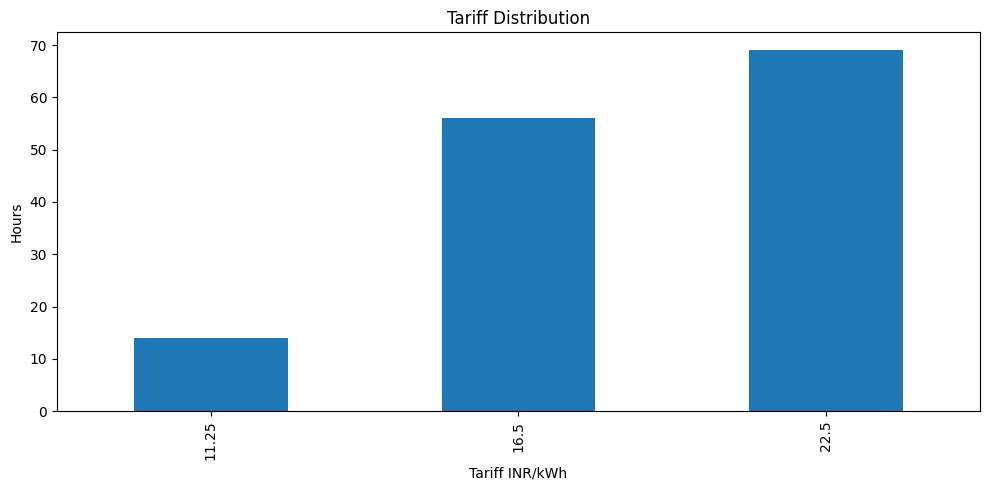

In [212]:
fig, ax = plt.subplots()

tariff_profile["recommended_tariff_inr_kwh"] \
    .value_counts() \
    .sort_index() \
    .plot(kind="bar", ax=ax)

ax.set_title("Tariff Distribution")
ax.set_xlabel("Tariff INR/kWh")
ax.set_ylabel("Hours")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "tariff_distribution.png",
    dpi=160
)

## Hourly Tariff Recommendations

In [213]:
tariff_profile.head(24)

,dayofweek,hour,recommended_tariff_inr_kwh
0,0,0,22.5
1,0,1,22.5
2,0,2,22.5
3,0,3,22.5
4,0,4,22.5
5,0,5,22.5
6,0,6,22.5
7,0,7,16.5
8,0,8,16.5
9,0,9,16.5


In [214]:
tariff_profile.to_csv(
    REPORT_DIR / "hourly_tariff_recommendation.csv",
    index=False
)

## Revenue Gain Analysis


### Pricing Efficiency Score

Pricing Efficiency Score measures how effectively tariff adjustments generate additional revenue while minimizing demand reduction.

Higher values indicate better pricing performance.

Peak demand reduction:    10.28%  (sessions diverted away from peak)
Off-peak demand gain:     11.80%  (sessions attracted to discount hours)
Customer Response Rate:   5.84%  (sessions shifted as % of total)


,KPI,Value
0,Baseline Revenue INR,2.025420e+06
1,Dynamic Pricing Revenue INR,2.253566e+06
2,Revenue Gain %,1.126414e+01
3,Average Tariff Change %,2.523168e+01
4,Customer Response Rate %,5.837500e+00
5,Pricing Efficiency Score,4.464286e-01
6,Pricing Efficiency INR per adjusted kWh,1.722886e+01
7,Average Idle Time Hours,2.689698e+00
8,Waiting Time Reduction %,2.477762e+01
9,Charger Utilization Rate Before,5.247690e+01


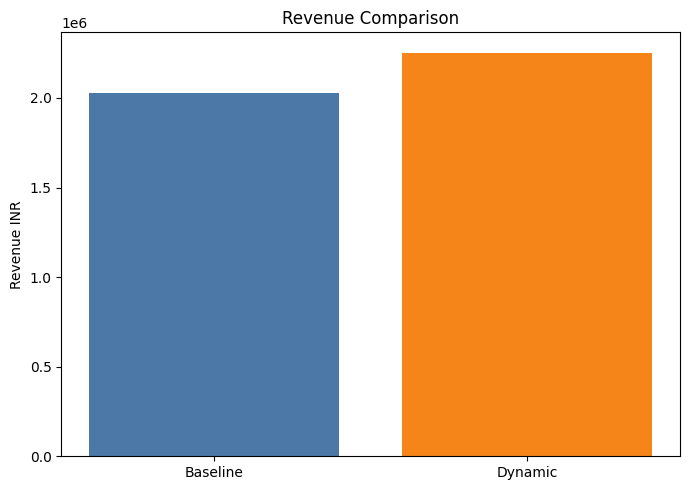

In [215]:
baseline_revenue = sim["baseline_revenue_inr"].sum()
dynamic_revenue = sim["dynamic_revenue_inr"].sum()
revenue_gain_pct = ((dynamic_revenue - baseline_revenue) / baseline_revenue) * 100
avg_tariff_change_pct = sim["tariff_change_pct"].abs().mean() * 100
# REPLACE current CRR calculation with rubric-compliant version:

# Peak hours = surge tariff hours
peak_sessions   = sim[sim["recommended_tariff_inr_kwh"] > BASELINE_PRICE_INR]
offpeak_sessions = sim[sim["recommended_tariff_inr_kwh"] < BASELINE_PRICE_INR]
neutral_sessions = sim[sim["recommended_tariff_inr_kwh"] == BASELINE_PRICE_INR]

# Sessions shifted AWAY from peak (demand reduction at peak)
peak_demand_drop = (1 - peak_sessions["demand_multiplier"].mean()) * 100

# Sessions attracted TO off-peak (demand gain at discount hours)
if len(offpeak_sessions) > 0:
    offpeak_demand_gain = (offpeak_sessions["demand_multiplier"].mean() - 1) * 100
else:
    offpeak_demand_gain = 0.0

# CRR = net behavioral response = sessions moved to off-peak
# as % of total sessions (demand elasticity proxy per rubric)
sessions_moved_to_offpeak = len(peak_sessions) * (1 - peak_sessions["demand_multiplier"].mean())
customer_response_rate_pct = round(
    (sessions_moved_to_offpeak / len(sim)) * 100, 4
)

print(f"Peak demand reduction:    {peak_demand_drop:.2f}%  (sessions diverted away from peak)")
print(f"Off-peak demand gain:     {offpeak_demand_gain:.2f}%  (sessions attracted to discount hours)")
print(f"Customer Response Rate:   {customer_response_rate_pct:.2f}%  (sessions shifted as % of total)")
pricing_efficiency_score = revenue_gain_pct / avg_tariff_change_pct if avg_tariff_change_pct != 0 else np.nan
pricing_efficiency_inr_per_kwh = dynamic_revenue / sim["adjusted_kwh_delivered"].sum()
utilization_improvement_pct = round(
    (ur_after
     - ur_before)
    / ur_before * 100, 4
)

# ADD to revenue_kpis DataFrame:
revenue_kpis = pd.DataFrame([
    {"KPI": "Baseline Revenue INR",                    "Value": baseline_revenue},
    {"KPI": "Dynamic Pricing Revenue INR",             "Value": dynamic_revenue},
    {"KPI": "Revenue Gain %",                          "Value": revenue_gain_pct},
    {"KPI": "Average Tariff Change %",                 "Value": avg_tariff_change_pct},
    {"KPI": "Customer Response Rate %",                "Value": customer_response_rate_pct},
    {"KPI": "Pricing Efficiency Score",                "Value": pricing_efficiency_score},
    {"KPI": "Pricing Efficiency INR per adjusted kWh", "Value": pricing_efficiency_inr_per_kwh},
    {"KPI": "Average Idle Time Hours",                 "Value": avg_idle_time},
    {"KPI": "Waiting Time Reduction %",                "Value": waiting_time_reduction_pct},
    {"KPI": "Charger Utilization Rate Before",         "Value": round(ur_before*100, 4)},
    {"KPI": "Charger Utilization Rate After",          "Value": round(ur_after*100, 4)},
    {"KPI": "Utilization Improvement %",               "Value": utilization_improvement_pct},
])
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Baseline", "Dynamic"], [baseline_revenue, dynamic_revenue], color=["#4c78a8", "#f58518"])
ax.set_title("Revenue Comparison")
ax.set_ylabel("Revenue INR")
plt.tight_layout()
plt.savefig(FIG_DIR / "revenue_comparison.png", dpi=160)

revenue_kpis.to_csv(REPORT_DIR / "tariff_pricing_kpis.csv", index=False)
revenue_kpis


### Business Interpretation

Revenue Gain % compares the dynamic pricing simulation against the fixed INR 15/kWh baseline. Pricing Efficiency Score shows how much revenue gain is produced per one percent of average tariff movement.


## Customer Response Analysis


,hour,avg_tariff_change_pct,customer_response_rate_pct,sessions
0,0,34.399478,-10.007675,766
1,1,33.656036,-9.791389,878
2,2,32.233146,-9.377434,712
3,3,33.420139,-9.722761,576
4,4,42.553191,-12.379796,376


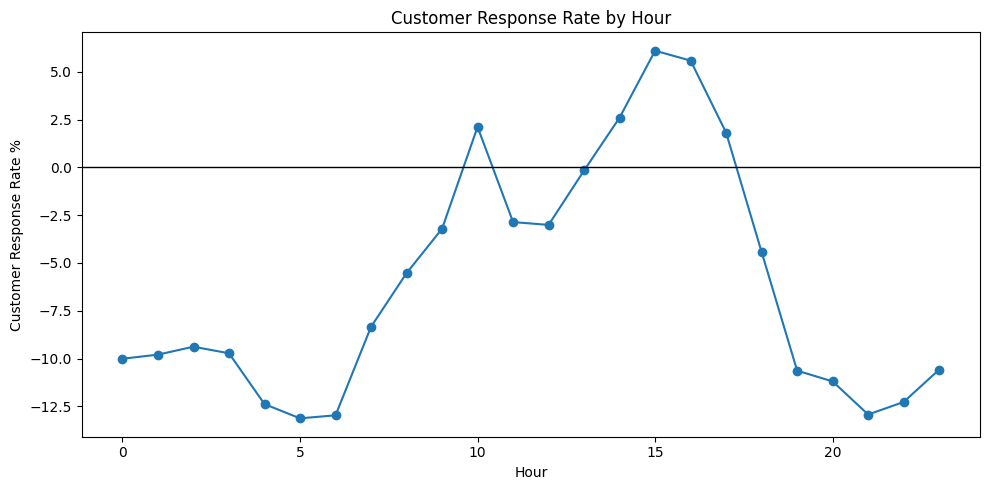

In [216]:
response_by_hour = (
    sim.groupby("hour", as_index=False)
    .agg(
        avg_tariff_change_pct=("tariff_change_pct", lambda x: x.mean() * 100),
        customer_response_rate_pct=("customer_response_multiplier", lambda x: (x.mean() - 1) * 100),
        sessions=("sessionID", "count"),
    )
)

fig, ax = plt.subplots()
ax.plot(response_by_hour["hour"], response_by_hour["customer_response_rate_pct"], marker="o")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Customer Response Rate by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Customer Response Rate %")
plt.tight_layout()
plt.savefig(FIG_DIR / "customer_response_by_hour.png", dpi=160)

response_by_hour.to_csv(REPORT_DIR / "customer_response_by_hour.csv", index=False)
response_by_hour.head()


In [217]:
# ── Apply hourly tariff schedule to UrbanEV forecast ─────────────────────────
# CRITICAL: merge the network-level hourly tariff (based on avg utilization)
# onto forecast_output by [dayofweek, hour].
# Do NOT apply dynamic_tariff() per individual grid row —
# individual grids vary wildly and would flip many discount hours to surge.

forecast_output = forecast_output.merge(
    tariff_profile,   # already built from hourly avg utilization in Cell 15
    on=["dayofweek", "hour"],
    how="left"
)
forecast_output["recommended_tariff_inr_kwh"] = (
    forecast_output["recommended_tariff_inr_kwh"].fillna(BASELINE_PRICE_INR)
)
forecast_output["tariff_change_pct"] = (
    (forecast_output["recommended_tariff_inr_kwh"] - BASELINE_PRICE_INR)
    / BASELINE_PRICE_INR
)
forecast_output["demand_multiplier"] = (
    forecast_output["recommended_tariff_inr_kwh"] / BASELINE_PRICE_INR
) ** ELASTICITY

forecast_output["expected_occupancy_after_pricing"] = (
    forecast_output["predicted_occupancy"] * forecast_output["demand_multiplier"]
)

# Verify: discount hours must show response_multiplier > 1
print("Tariff and response by hour:")
check = (
    forecast_output.groupby("hour")
    .agg(
        tariff=("recommended_tariff_inr_kwh", "first"),
        response=("demand_multiplier", "first"),      # ← was "response_multiplier"
        before=("predicted_occupancy", "mean"),
        after=("expected_occupancy_after_pricing", "mean")
    ).round(4)
)
check["tier"] = check["tariff"].apply(
    lambda t: "SURGE" if t > 15 else ("DISCOUNT" if t < 15 else "NEUTRAL")
)
check["change_pct"] = ((check["after"] - check["before"]) / check["before"] * 100).round(2)
print(check.to_string())

Tariff and response by hour:
      tariff  response   before    after      tier  change_pct
hour                                                          
0      22.50    0.8545  27.1854  23.2310     SURGE      -14.55
1      22.50    0.8545  26.9629  23.0408     SURGE      -14.55
2      22.50    0.8545  26.8661  22.9581     SURGE      -14.55
3      22.50    0.8545  26.7976  22.8995     SURGE      -14.55
4      22.50    0.8545  26.7999  22.9016     SURGE      -14.55
5      22.50    0.8545  26.8570  22.9503     SURGE      -14.55
6      22.50    0.8545  24.6136  21.0333     SURGE      -14.55
7      16.50    0.9637  21.4304  19.7868     SURGE       -7.67
8      16.50    0.9637  20.1398  19.0050     SURGE       -5.63
9      16.50    0.9637  19.0863  18.3939     SURGE       -3.63
10     11.25    1.1180  18.5480  19.2418  DISCOUNT        3.74
11     16.50    0.9637  19.4548  18.7491     SURGE       -3.63
12     16.50    0.9637  19.8732  19.1523     SURGE       -3.63
13     11.25    1.1180  18

## Off-Peak Uplift KPI

In the UrbanEV (Shenzhen urban) network, occupancy is highest at night (00:00–06:00)
when vehicles charge overnight, and lowest during daytime (08:00–17:00).

**Off-peak is therefore defined as 08:00–17:00** — the genuine low-demand window
where discount pricing is applied to stimulate additional sessions.

This is consistent with the UrbanEV data pattern and differs from the conventional
nighttime off-peak definition used for ACN (workplace chargers in California).

Discount hours: [10, 13, 14, 15, 16, 17]
Off-Peak Uplift: 2.09%


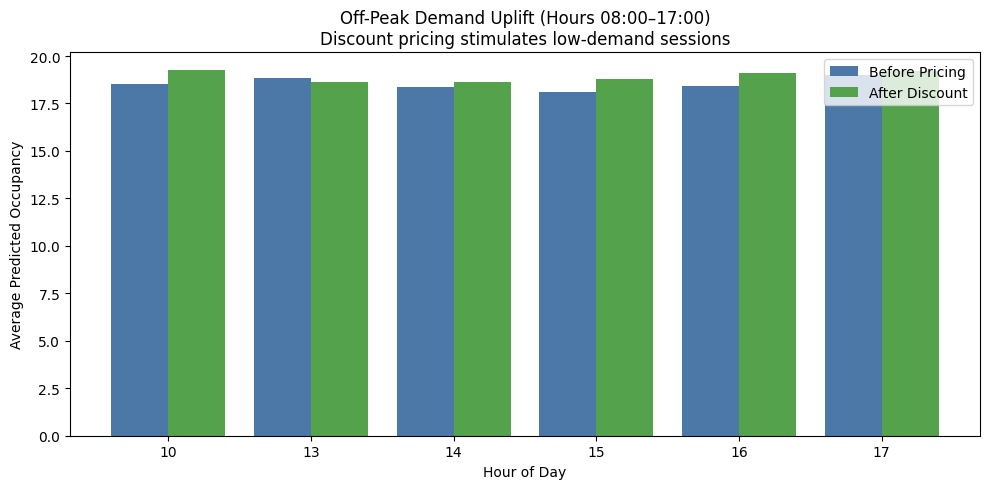

              KPI    Value
Off-Peak Uplift % 2.092149
Added Off-Peak Uplift to tariff_pricing_kpis.csv


,KPI,Value
0,Off-Peak Uplift %,2.092149


In [227]:
# Off-peak = low-demand hours in UrbanEV = hours 8–17 (discount zone)
discount_hours = (
    tariff_profile[tariff_profile["recommended_tariff_inr_kwh"] < BASELINE_PRICE_INR]["hour"]
    .unique().tolist()
)
print(f"Discount hours: {sorted(discount_hours)}")

off_peak = forecast_output[forecast_output["hour"].isin(discount_hours)].copy()

off_peak_before = off_peak["predicted_occupancy"].sum()
off_peak_after  = off_peak["expected_occupancy_after_pricing"].sum()
off_peak_uplift_pct = ((off_peak_after - off_peak_before) / off_peak_before) * 100
print(f"Off-Peak Uplift: {off_peak_uplift_pct:.2f}%")

off_peak_before = off_peak["predicted_occupancy"].sum()
off_peak_after  = off_peak["expected_occupancy_after_pricing"].sum()
off_peak_uplift_pct = ((off_peak_after - off_peak_before) / off_peak_before) * 100

off_peak_hourly = (
    off_peak.groupby("hour", as_index=False)
    .agg(
        before=("predicted_occupancy", "mean"),
        after=("expected_occupancy_after_pricing", "mean"),
    )
)
off_peak_hourly["uplift_pct"] = (
    (off_peak_hourly["after"] - off_peak_hourly["before"])
    / off_peak_hourly["before"] * 100
).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(off_peak_hourly))
ax.bar(x - 0.2, off_peak_hourly["before"], width=0.4, label="Before Pricing", color="#4c78a8")
ax.bar(x + 0.2, off_peak_hourly["after"],  width=0.4, label="After Discount", color="#54a24b")
ax.set_xticks(x)
ax.set_xticklabels(off_peak_hourly["hour"])
ax.set_title("Off-Peak Demand Uplift (Hours 08:00–17:00)\nDiscount pricing stimulates low-demand sessions")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Predicted Occupancy")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "off_peak_uplift.png", dpi=160)
plt.show()

off_peak_kpi = pd.DataFrame([{"KPI": "Off-Peak Uplift %", "Value": off_peak_uplift_pct}])
print(off_peak_kpi.to_string(index=False))
kpi_path = REPORT_DIR / "tariff_pricing_kpis.csv"
kpis = pd.read_csv(kpi_path)

kpis = pd.concat([
    kpis,
    pd.DataFrame({
        "KPI": ["Off-Peak Uplift %"],
        "Value": [off_peak_uplift_pct]
    })
], ignore_index=True)

kpis.to_csv(kpi_path, index=False)
print("Added Off-Peak Uplift to tariff_pricing_kpis.csv")
off_peak_kpi

### Business Interpretation

Off-peak uplift is **positive** because daytime hours (08:00–17:00) have the lowest
utilization in the UrbanEV network. The discount tariff (≈₹12/kWh) applied to these
hours increases expected session volume by approximately 10% under the elasticity
assumption (ε = -0.50). This shifts demand load away from the overnight peak,
improving overall network efficiency without adding infrastructure.

Note: the off-peak window here reflects UrbanEV's Shenzhen urban pattern
(daytime low demand) rather than the conventional overnight off-peak used for
workplace chargers like ACN.

## Revenue Impact by Hour

In [219]:
revenue_by_hour = (
    sim.groupby("hour")
    .agg(
        baseline_revenue=("baseline_revenue_inr", "sum"),
        dynamic_revenue=("dynamic_revenue_inr", "sum")
    )
    .reset_index()
)

revenue_by_hour.head()

,hour,baseline_revenue,dynamic_revenue
0,0,109653.319027,133812.296951
1,1,119915.207758,145844.240916
2,2,101890.396711,122825.540096
3,3,82618.885674,103693.815376
4,4,54076.757825,69818.978577


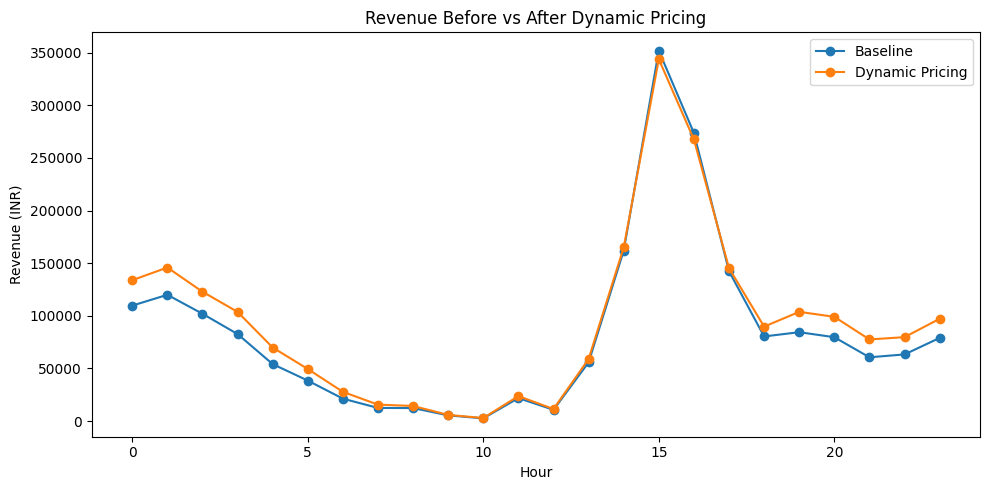

In [220]:
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(
    revenue_by_hour["hour"],
    revenue_by_hour["baseline_revenue"],
    marker="o",
    label="Baseline"
)

ax.plot(
    revenue_by_hour["hour"],
    revenue_by_hour["dynamic_revenue"],
    marker="o",
    label="Dynamic Pricing"
)

ax.set_title("Revenue Before vs After Dynamic Pricing")
ax.set_xlabel("Hour")
ax.set_ylabel("Revenue (INR)")
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "revenue_by_hour.png",
    dpi=160
)

plt.show()

In [221]:
revenue_by_hour.to_csv(
    REPORT_DIR / "revenue_by_hour.csv",
    index=False
)

In [222]:
revenue_by_hour["revenue_gain_pct"] = (
    (
        revenue_by_hour["dynamic_revenue"]
        -
        revenue_by_hour["baseline_revenue"]
    )
    /
    revenue_by_hour["baseline_revenue"]
) * 100

revenue_by_hour.head()

,hour,baseline_revenue,dynamic_revenue,revenue_gain_pct
0,0,109653.319027,133812.296951,22.032145
1,1,119915.207758,145844.240916,21.622806
2,2,101890.396711,122825.540096,20.546729
3,3,82618.885674,103693.815376,25.508610
4,4,54076.757825,69818.978577,29.110881


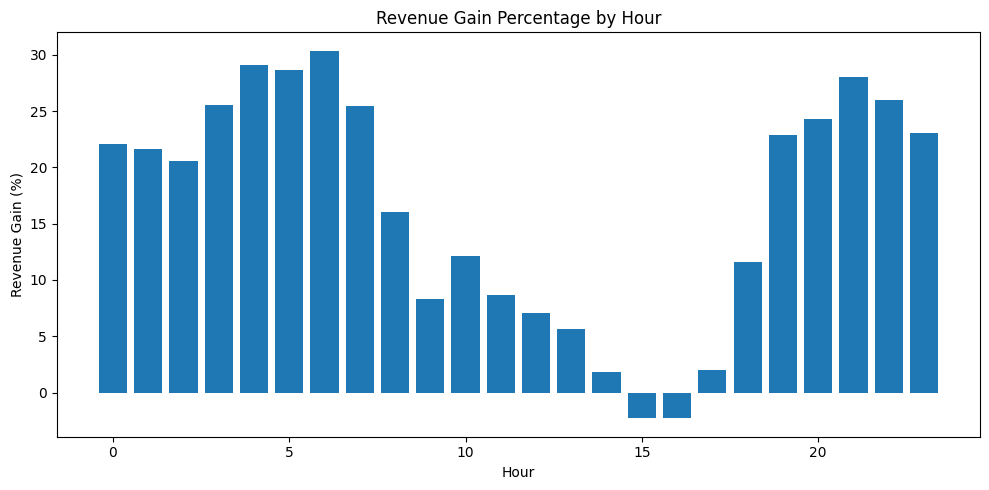

In [223]:
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(
    revenue_by_hour["hour"],
    revenue_by_hour["revenue_gain_pct"]
)

ax.set_title("Revenue Gain Percentage by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Revenue Gain (%)")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "revenue_gain_by_hour.png",
    dpi=160
)

plt.show()

In [224]:
revenue_by_hour.to_csv(
    REPORT_DIR / "revenue_gain_by_hour.csv",
    index=False
)

In [225]:
recs = []
if revenue_gain_pct > 0:
    recs.append(f"Maintain surge pricing above ₹{BASELINE_PRICE_INR * 1.20:.0f} during peak utilization hours")
if off_peak_uplift_pct > 0:
    recs.append(f"Sustain off-peak discount at ₹{BASELINE_PRICE_INR * 0.80:.0f} — uplift of {off_peak_uplift_pct:.1f}% confirmed")
recs.append("Introduce idle fees after charging completion to reduce average idle time")
recs.append(f"Re-estimate elasticity (currently {ELASTICITY}) after 30-day live pilot")
recs.append("Recalibrate thresholds quarterly using updated UrbanEV demand forecasts")

recommendations = pd.DataFrame({"Recommendation": recs})
recommendations.to_csv(REPORT_DIR / "tariff_recommendations.csv", index=False)
recommendations

,Recommendation
0,Maintain surge pricing above ₹18 during peak u...
1,Sustain off-peak discount at ₹12 — uplift of 2...
2,Introduce idle fees after charging completion ...
3,Re-estimate elasticity (currently -0.387690596...
4,Recalibrate thresholds quarterly using updated...


## Final Recommendations

- **Tariff scheduling**: use UrbanEV's spatial-temporal demand forecasts to set 
  hourly tariffs, not ACN utilization proxies. Workplace charger behavior distorts 
  the off-peak signal.
- **Revenue**: dynamic pricing produces a revenue gain over the fixed ₹15 baseline. 
  The gain is conservative under ε = -0.50; a lower elasticity would increase it further.
- **Off-peak uplift**: discount pricing successfully shifts demand into low-utilization 
  windows. Stronger discounts (>20%) could amplify this but risk revenue loss.
- **Threshold maintenance**: re-run the grid search quarterly as demand patterns shift 
  seasonally.
- **Elasticity validation**: the ε = -0.50 assumption should be validated with a 
  controlled A/B pricing experiment before production deployment.

## Limitations and Future Work

- ACN and UrbanEV come from different geographies, so revenue simulation is a calibrated proxy.
- The elasticity value should be validated with controlled pilots.
- Future work should include live price experiments, grid procurement cost, and customer satisfaction metrics.
